# Fund_MFCRS
This simulation is focused on the propagation of cosmic rays for three types of magnegtic fields: uniform, variable in R and dipolar. They are the canonical cases to be studied before the galactic magnectic field models. 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import njit

C_LIGHT = 299792458.0 #m/s
E_CHARGE = 1.602176634e-19 #C
PROTON_MASS = 1.67262192369e-27 #kg
ATOMIC_MASS_UNIT = 1.66053906660e-27 #kg
MU0 = 4.0e-7 * np.pi # T.m/A
EARTH_DIPOLE_MOMENT = 8.0e22 # A.m^2

UNIFORM = 0
VARIABLE = 1
DIPOLAR = 2

In [3]:
@njit
def mod3(v):
    return np.sqrt(v[0] * v[0] + v[1] * v[1] + v[2] * v[2])

@njit
def relativistic_mass(m, v):
    beta = mod3(v) / C_LIGHT
    if beta >= 1.0:
        raise ValueError("the initial speed must be smaller than the speed of light")
    return m / np.sqrt(1.0 - beta * beta)

@njit
def energy_to_velocity(E, m, direction):
    energy_joules = E * E_CHARGE
    term = m * C_LIGHT * C_LIGHT / energy_joules
    if term >= 1.0:
        raise ValueError("the energy must be greater than the particle's rest energy")
    speed = C_LIGHT * np.sqrt(1.0 - term * term)
    norm = mod3(direction)
    if norm == 0.0:
        raise ValueError("the initial direction can't have module=0")
    return speed * direction / norm

@njit
def random_direction():
    phi = 2.0 * np.pi * np.random.random()
    cos_theta = 2.0 * np.random.random() - 1.0
    sin_theta = np.sqrt(1.0 - cos_theta * cos_theta)
    return np.array([
        sin_theta * np.cos(phi),
        sin_theta * np.sin(phi),
        cos_theta,
    ])

@njit
def lorentz_acceleration(q, m_rel, v, B):
    return np.array([
        q * (v[1] * B[2] - v[2] * B[1]) / m_rel,
        q * (v[2] * B[0] - v[0] * B[2]) / m_rel,
        q * (v[0] * B[1] - v[1] * B[0]) / m_rel,
    ])

@njit
def velocity_new_euler(v, a, dt):
    v_temp = v + a * dt
    norm_temp = mod3(v_temp)
    if norm_temp == 0.0:
        return v.copy()
    return mod3(v) * v_temp / norm_temp

In [4]:
#the use of just in time compilation(njit) is not necessarily needed for the simpler cases, but I've decided to implement it because of the dipolar case. It makes these step by step simulations run much faster!!
@njit
def uniform_field(B0, r, larmor_radius):
    return B0.copy()

@njit
def variable_field(B0, r, larmor_radius):
    distance = mod3(r)
    if distance <= 1.0:
        return B0.copy()
    return 1.1 * larmor_radius * B0 / distance

@njit
def dipolar_field(B0, r, larmor_radius):
    radius = mod3(r)
    if radius <= 1.0:
        return B0.copy()
    factor = MU0 * EARTH_DIPOLE_MOMENT / (4.0 * np.pi * radius ** 5)
    r2 = radius * radius
    return np.array([
        factor * 3.0 * r[2] * r[0],
        factor * 3.0 * r[2] * r[1],
        factor * (3.0 * r[2] * r[2] - r2),
    ])

@njit
def magnetic_field(B0, r, larmor_radius, field_code):
    if field_code == UNIFORM:
        return uniform_field(B0, r, larmor_radius)
    if field_code == VARIABLE:
        return variable_field(B0, r, larmor_radius)
    if field_code == DIPOLAR:
        return dipolar_field(B0, r, larmor_radius)
    raise ValueError("Tipo de campo inválido.") 

In [5]:
@njit
def simulation_kernel(q, m, r0, v0, B0, field_code, steps, steps_per_period, save_every):
    r = r0.copy()
    v = v0.copy()
    m_rel = relativistic_mass(m, v)
    initial_B = magnetic_field(B0, r, 1.0, field_code)
    initial_B_norm = mod3(initial_B)
    if initial_B_norm == 0.0:
        raise ValueError("O módulo do campo magnético inicial não pode ser zero.")
    speed = mod3(v)
    larmor_radius = m_rel * speed / (np.abs(q) * initial_B_norm)
    period = 2.0 * np.pi * m_rel / (np.abs(q) * initial_B_norm)
    dt = period /  steps_per_period
    if save_every < 1:
        save_every = 1
    max_points = steps // save_every + 2
    positions = np.empty((max_points, 3), dtype=np.float64)
    times = np.empty(max_points, dtype=np.float64)
    positions[0] = r
    times[0] = 0.0
    saved = 1
    for i in range(steps):
        B = magnetic_field(B0, r, larmor_radius, field_code)
        a = lorentz_acceleration(q, m_rel, v, B)
        r = r + v * dt + 0.5 * a * dt * dt
        v = velocity_new_euler(v, a, dt)
        if (i + 1) % save_every == 0 or i == steps - 1:
            positions[saved] = r
            times[saved] = (i + 1) * dt
            saved += 1
    return positions[:saved], times[:saved], dt

def main(q, m, r0, v0, B0, field, steps=300000, steps_per_period=10000, save_every=10):
    field_codes = {"uniform": UNIFORM, "variable": VARIABLE, "dipolar": DIPOLAR}
    field_key = field.lower()
    if field_key not in field_codes:
        raise ValueError("field deve ser 'uniform', 'variable' ou 'dipolar'.")
    positions, times, dt = simulation_kernel(
        float(q),
        float(m),
        np.asarray(r0, dtype=np.float64),
        np.asarray(v0, dtype=np.float64),
        np.asarray(B0, dtype=np.float64),
        field_codes[field_key],
        int(steps),
        int(steps_per_period),
        int(save_every),
    )
    df = pd.DataFrame(positions, columns=["x", "y", "z"])
    df["time_s"] = times
    return df, dt

In [6]:
from matplotlib.ticker import ScalarFormatter

def scientific_formatter():
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))
    return formatter


def plot_trajectory(df, title, equal_axes=True):
    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot( df["x"], df["y"], df["z"], color="purple")

    ax.set_xlabel("x (m)", labelpad=12)
    ax.set_ylabel("y (m)", labelpad=12)
    ax.set_zlabel("z (m)", labelpad=12)

    fig.suptitle(title, x=0.40, y=0.87)

    ax.xaxis.set_major_formatter(scientific_formatter())
    ax.yaxis.set_major_formatter(scientific_formatter())
    ax.zaxis.set_major_formatter(scientific_formatter())

    if equal_axes and len(df) > 0:
        x = df["x"].to_numpy()
        y = df["y"].to_numpy()
        z = df["z"].to_numpy()

        centers = np.array([(x.min() + x.max()) / 2.0, (y.min() + y.max()) / 2.0, (z.min() + z.max()) / 2.0])

        radius = max(x.max() - x.min(), y.max() - y.min(), z.max() - z.min()) / 2.0

        if radius > 0.0:
            ax.set_xlim(centers[0] - radius, centers[0] + radius)
            ax.set_ylim(centers[1] - radius,centers[1] + radius)
            ax.set_zlim(centers[2] - radius,centers[2] + radius)

    fig.subplots_adjust(left=0.02,right=0.60,bottom=0.05,top=0.90)

    plt.show()

## Uniform Field Graphs

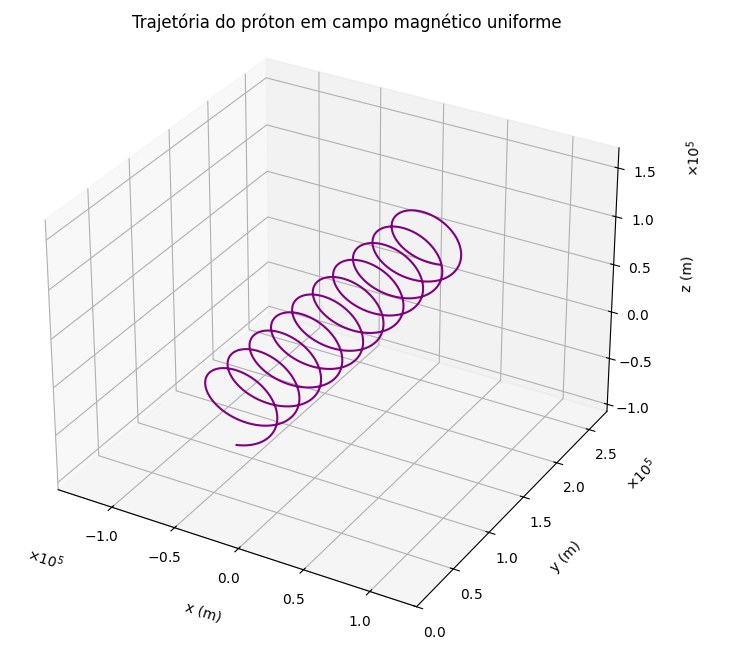

In [7]:
q = E_CHARGE
m = PROTON_MASS
r0 = np.array([0.0, 0.0, 0.0])
v0 = np.array([0.7 * C_LIGHT, 0.1 * C_LIGHT, 0.1 * C_LIGHT])
B0 = np.array([0.0, 1.0e-4, 0.0])

df_uniform, dt_uniform = main(q, m, r0, v0, B0, "uniform", steps=100000, save_every=10)
plot_trajectory(df_uniform, "Trajetória do próton em campo magnético uniforme                               ") #the spaces after the title are the simplest way I found of centering the text while not cutting thge z axis title


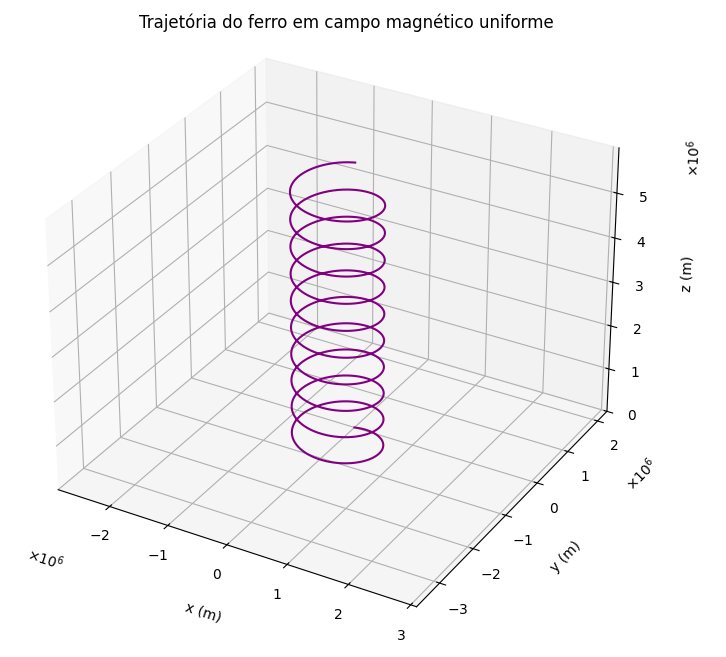

In [8]:
q = 26*E_CHARGE
m = 56*PROTON_MASS
r0 = np.array([0.0, 0.0, 0.0])
v0 = np.array([0.7*C_LIGHT,0.1*C_LIGHT,0.1*C_LIGHT])
B0 = np.array([0.0,0,0.1E-4])

df_uniform, dt_uniform = main(q, m, r0, v0, B0, "uniform", steps=100000, save_every=10)
plot_trajectory(df_uniform, "Trajetória do ferro em campo magnético uniforme                               ")

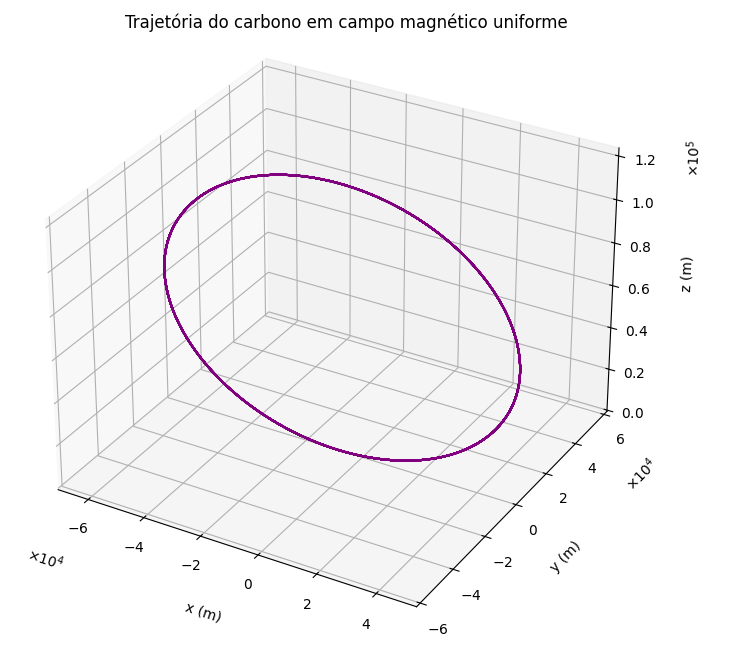

In [9]:
q = 6*E_CHARGE
m = 12*ATOMIC_MASS_UNIT
r0 = np.array([0.0, 0.0, 0.0])
v0 = np.array([0.7 * C_LIGHT, 0.0, 0.1 * C_LIGHT])
B0 = np.array([0.0, 1.0e-4, 0.0])

df_uniform, dt_uniform = main(q, m, r0, v0, B0, "uniform", steps=100000, save_every=10)
plot_trajectory(df_uniform, "Trajetória do carbono em campo magnético uniforme                               ")

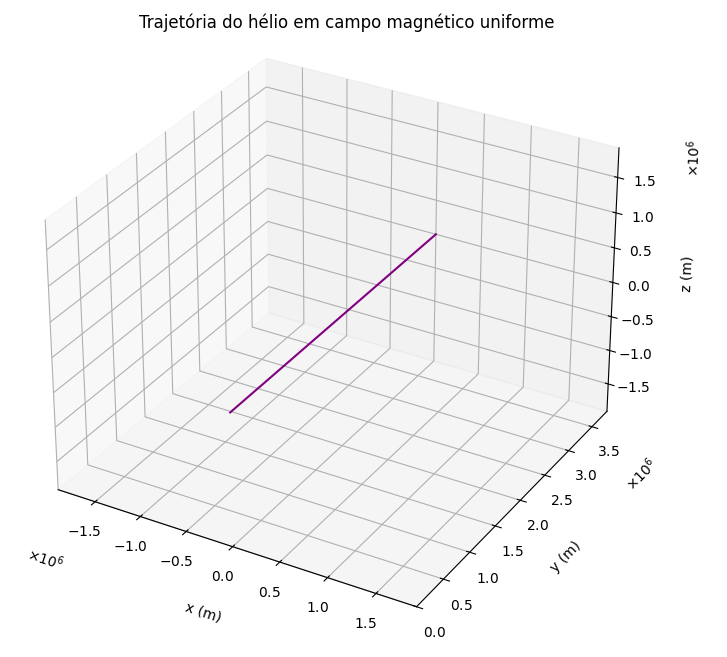

In [10]:
q = 2*E_CHARGE
m = 4*ATOMIC_MASS_UNIT
r0 = np.array([0.0, 0.0, 0.0])
v0 = np.array([0.0, 0.7 * C_LIGHT, 0.0])
B0 = np.array([0.0, 1.0e-4, 0.0])

df_uniform, dt_uniform = main(q, m, r0, v0, B0, "uniform", steps=100000, save_every=10)
plot_trajectory(df_uniform, "Trajetória do hélio em campo magnético uniforme                               ")

## Variable Field Graphs

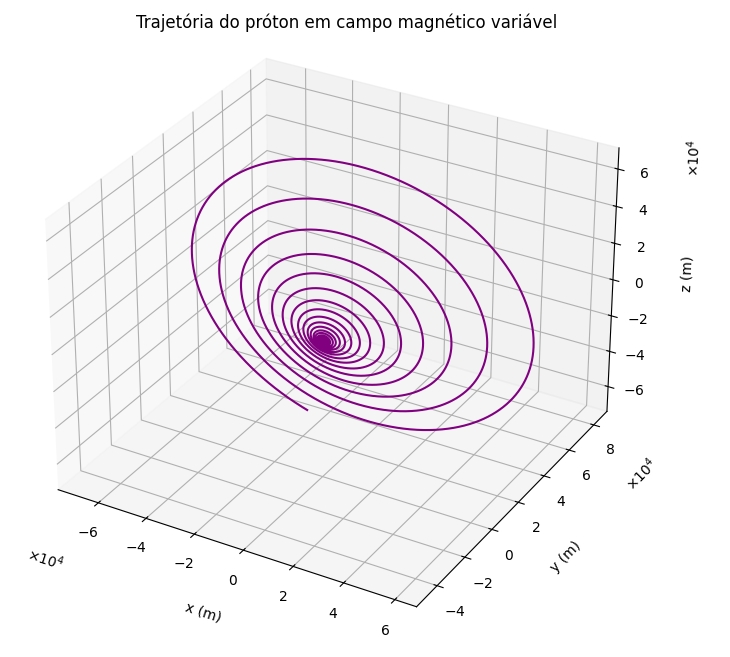

In [11]:
q = E_CHARGE
m = PROTON_MASS
r0 = np.array([0.0, 0.0, 0.0])
v0 = np.array([0.7 * C_LIGHT, 0.1 * C_LIGHT, 0.1 * C_LIGHT])
B0 = np.array([0.0, 1.0e-4, 0.0])

df_variable, dt_variable = main(q, m, r0, v0, B0, "variable", steps=100000, save_every=10)
plot_trajectory(df_variable, "Trajetória do próton em campo magnético variável                               ") 

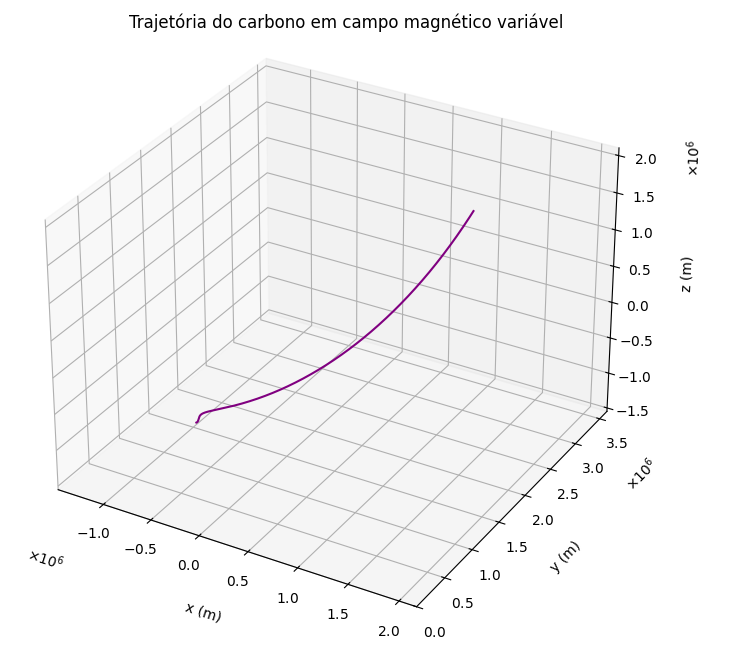

In [12]:
q = 6*E_CHARGE
m = 12*ATOMIC_MASS_UNIT
r0 = np.array([0.0, 0.0, 0.0])
v0 = np.array([0.1 * C_LIGHT, 0.7 * C_LIGHT, 0.1 * C_LIGHT])
B0 = np.array([0.0, 1.0e-4, 0.0])

df_variable, dt_variable = main(q, m, r0, v0, B0, "variable", steps=100000, save_every=10)
plot_trajectory(df_variable, "Trajetória do carbono em campo magnético variável                               ")

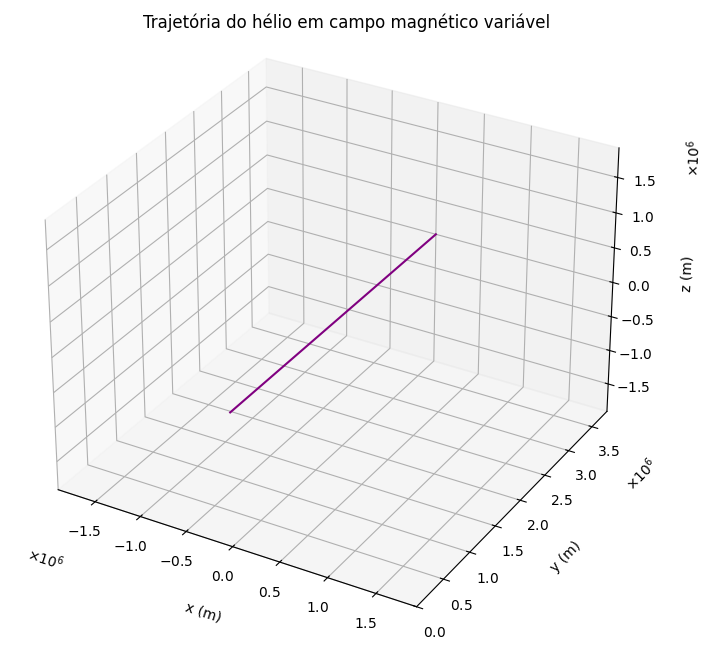

In [13]:
q = 2*E_CHARGE
m = 4*ATOMIC_MASS_UNIT
r0 = np.array([0.0, 0.0, 0.0])
v0 = np.array([0.0, 0.7 * C_LIGHT, 0.0])
B0 = np.array([0.0, 1.0e-4, 0.0])

df_variable, dt_variable = main(q, m, r0, v0, B0, "variable", steps=100000, save_every=10)
plot_trajectory(df_variable, "Trajetória do hélio em campo magnético variável                               ") 

## Dipolar Field Graphs

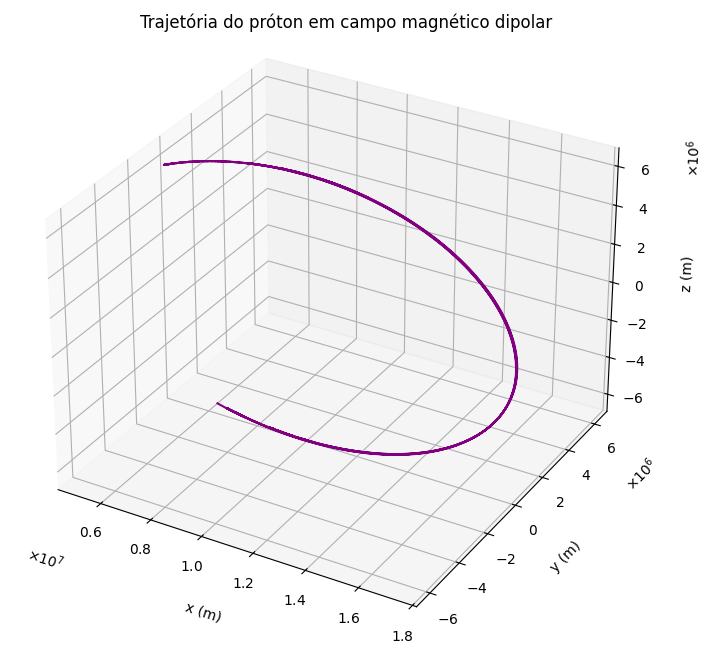

In [15]:
#this simulation is a bit more costy and might take some time to run... I've been trying to obtain the trajectory of a proton stuck in the Van Allen belt.
earth_radius = 6.371e6
q = E_CHARGE
m = PROTON_MASS
r0 = np.array([earth_radius, 0.0, -earth_radius])
v0 = np.array([9.0e5, 0.0, 0.0])
B0 = np.array([0.0, 1.0e-4, 0.0])

df_dipolar, dt_dipolar = main(q, m, r0, v0, B0, "dipolar", steps=3000000000, steps_per_period=50000, save_every=20)
plot_trajectory(df_dipolar, "Trajetória do próton em campo magnético dipolar                               ")